Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


预训练模型加载完成，开始生成图像：


  0%|          | 0/1000 [00:00<?, ?it/s]

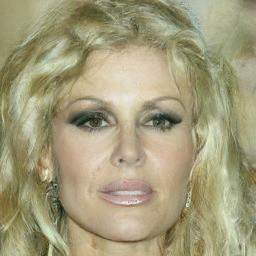

  0%|          | 0/50 [00:00<?, ?it/s]

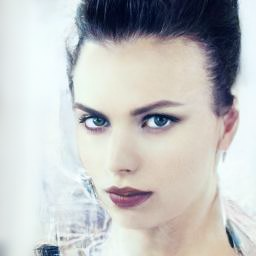

In [1]:
# 安装依赖
# pip install diffusers transformers accelerate torch

from diffusers import DDPMPipeline, DDIMPipeline, PNDMPipeline
import torch

# 加载预训练的DDPM模型（生成蝴蝶图像）
pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")
print("预训练模型加载完成，开始生成图像：")

# 使用相同的随机种子
generator = torch.Generator(device="cuda").manual_seed(42)

# 生成图像
image = pipe(generator=generator).images[0]
#image.save("generated_image.png")
# 在Jupyter Notebook中显示图像
# from IPython.display import display
display(image)

# 更快的采样方法
from diffusers import DDIMScheduler
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
image_fast = pipe(num_inference_steps=50, generator=generator).images[0]
#image_fast.save("generated_image_fast.png")
display(image_fast)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
C:\Users\Windows11\AppData\Local\Temp\ipykernel_14256\2435400121.py:15: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, pipe.unet.in_channels, 256, 256),


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


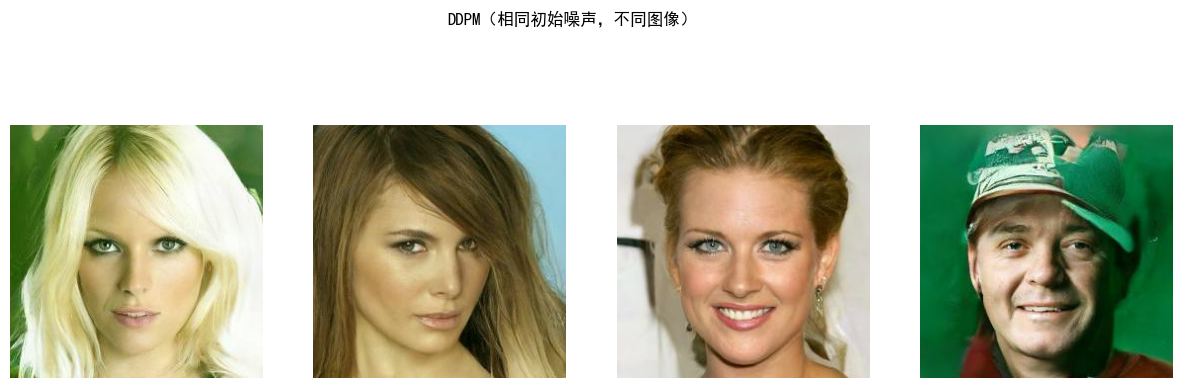

In [2]:
from diffusers import DDPMPipeline, DDIMScheduler
import torch
from PIL import Image
import matplotlib.pyplot as plt

def ddpm_custom_noise_generation(seed=42):
    """使用底层API实现真正的自定义噪声控制"""
    
    # 加载模型和调度器
    pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
    pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")
    
    # 创建完全自定义的噪声,使用固定种子
    custom_noise = torch.randn(
        (1, pipe.unet.in_channels, 256, 256),
        device=pipe.device,
        generator=torch.Generator(device=pipe.device).manual_seed(seed)
    )
    
    # 手动执行生成过程
    pipe.scheduler.set_timesteps(1000)
    
    # 从我们的自定义噪声开始
    sample = custom_noise
    
    for i, t in enumerate(pipe.scheduler.timesteps):
        # 预测噪声
        with torch.no_grad():
            noise_pred = pipe.unet(sample, t).sample
        
        # 使用调度器计算上一步的样本
        sample = pipe.scheduler.step(noise_pred, t, sample).prev_sample
    
    # 将输出转换为图像
    sample = (sample / 2 + 0.5).clamp(0, 1)
    image = sample.cpu().permute(0, 2, 3, 1).numpy()[0]
    image = (image * 255).round().astype("uint8")
    image = Image.fromarray(image)
    
    return image

# 使用相同的种子生成4张图像
images = [ddpm_custom_noise_generation(seed=42) for i in range(4)]


def show_image_grid(images, title):
    # 解决中文显示问题
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    """显示图像网格"""
    fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img in zip(axs, images):
        ax.imshow(img)
        ax.axis('off')
    plt.suptitle(title)
    plt.show()

show_image_grid(images, "DDPM（相同初始噪声，不同图像）")


### DDIM eta = 0（预期：4 张图完全一样）


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
C:\Users\Windows11\AppData\Local\Temp\ipykernel_14256\2900628509.py:10: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, pipe.unet.in_channels, 256, 256),


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


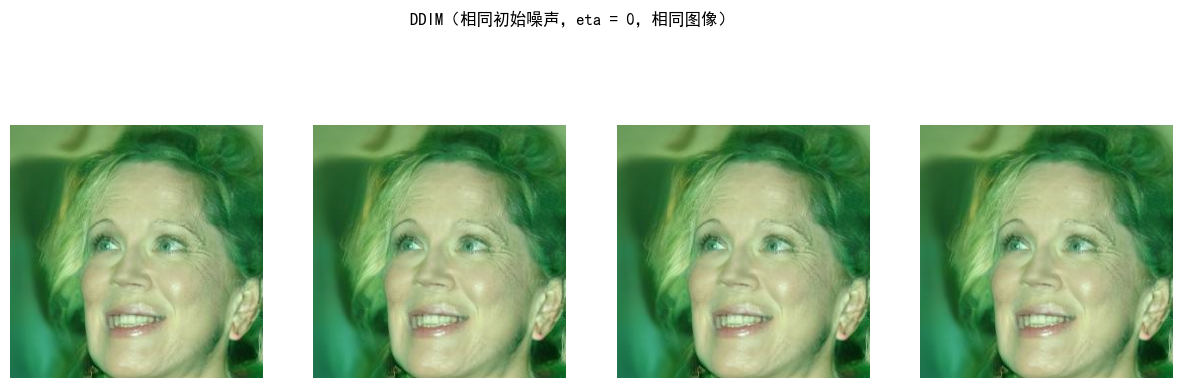


### DDIM eta = 0.2（预期：略有差异）


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


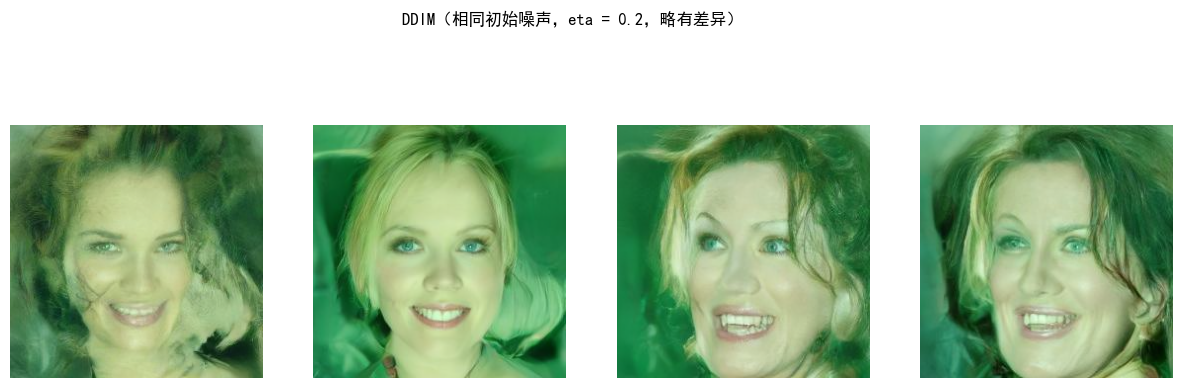


### DDIM eta = 1.0（预期：差异明显）， 与 DDPM 类似


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Windows11\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


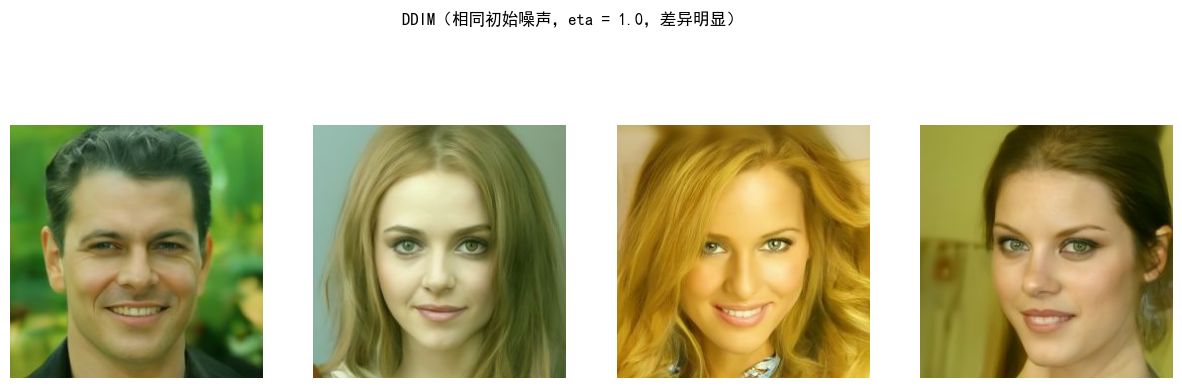

In [3]:
def ddim_custom_noise_generation(seed=42, eta=0.0):
    """使用底层API实现真正的自定义噪声控制"""

    # 加载模型和调度器
    pipe = DDIMPipeline.from_pretrained("google/ddpm-celebahq-256")
    pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")

    # 创建完全自定义的噪声,使用固定种子
    custom_noise = torch.randn(
        (1, pipe.unet.in_channels, 256, 256),
        device=pipe.device,
        generator=torch.Generator(device=pipe.device).manual_seed(seed)
    )

    # 手动执行生成过程
    pipe.scheduler.set_timesteps(50) # DDIM 通常使用更少的步数
    sample = custom_noise
    for i, t in enumerate(pipe.scheduler.timesteps):
        # 预测噪声
        with torch.no_grad():
            noise_pred = pipe.unet(sample, t).sample

        # 使用调度器计算上一步的样本
        sample = pipe.scheduler.step(noise_pred, t, sample, eta=eta).prev_sample

    # 将输出转换为图像
    sample = (sample / 2 + 0.5).clamp(0, 1)
    image = sample.cpu().permute(0, 2, 3, 1).numpy()[0]
    image = (image * 255).round().astype("uint8")
    image = Image.fromarray(image)

    return image
# 使用相同的种子生成4张图像
print("\n### DDIM eta = 0（预期：4 张图完全一样）")
images = [ddim_custom_noise_generation(seed=42, eta=0.0) for i in range(4)]
show_image_grid(images, "DDIM（相同初始噪声，eta = 0，相同图像）")

print("\n### DDIM eta = 0.2（预期：略有差异）")
images = [ddim_custom_noise_generation(seed=42, eta=0.2) for i in range(4)]
show_image_grid(images, "DDIM（相同初始噪声，eta = 0.2，略有差异）")

print("\n### DDIM eta = 1.0（预期：差异明显）， 与 DDPM 类似")
images = [ddim_custom_noise_generation(seed=42, eta=1.0) for i in range(4)]
show_image_grid(images, "DDIM（相同初始噪声，eta = 1.0，差异明显）")